# TPR Box Plot across different nT
This notebook loads TPR `.npz` files, splits the 1000 runs into 10 partitions, calculates the empirical TPR for each partition, and plots the distribution of these TPR values as grouped box plots across `nT`.

In [14]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Setup paths relative to this notebook
notebook_dir = Path.cwd().resolve()
repo_root = notebook_dir.parent
results_dir = repo_root / "run_experiment" / "results"

In [15]:
# Parameters used in the experiments
p = 300
nS = 120
K = 5
lambda_sel = 0.6
lambda0 = 0.7
alpha = 0.05
nT_list = [50, 75, 100]
num_partitions = 10

# Method configurations
methods = {
    'CoRT': {'name': 'CoRT-SI', 'color': '#ff0000'}, # Red
    'DS': {'name': 'DS', 'color': '#008000'},      # Green
    'bonf': {'name': 'Bonferroni', 'color': '#800080'} # Purple
}

all_data = []

# Load data
for method in methods:
    for nT in nT_list:
        file_path = results_dir / f"{method}_tpr_p{p}_nS{nS}_nT{nT}_K{K}_lamsel{lambda_sel}_lam0{lambda0}.npz"
        if file_path.exists():
            data = np.load(file_path)
            if 'null_pvalues' in data and 'j_values' in data:
                pvals = data['null_pvalues']
                jvals = data['j_values']
                
                if len(pvals) > 0:
                    # Split into 10 partitions
                    p_chunks = np.array_split(pvals, num_partitions)
                    j_chunks = np.array_split(jvals, num_partitions)
                    
                    for p_chunk, j_chunk in zip(p_chunks, j_chunks):
                        # TPR is evaluated ONLY on the true signal (j <= 5)
                        valid_mask = j_chunk <= 5
                        if np.sum(valid_mask) > 0:
                            tpr = np.mean(p_chunk[valid_mask] <= alpha)
                            all_data.append({
                                'nT': nT,
                                'Method': methods[method]['name'],
                                'TPR': tpr
                            })
                        else:
                            # No signal selected in this partition
                            all_data.append({
                                'nT': nT,
                                'Method': methods[method]['name'],
                                'TPR': np.nan
                            })

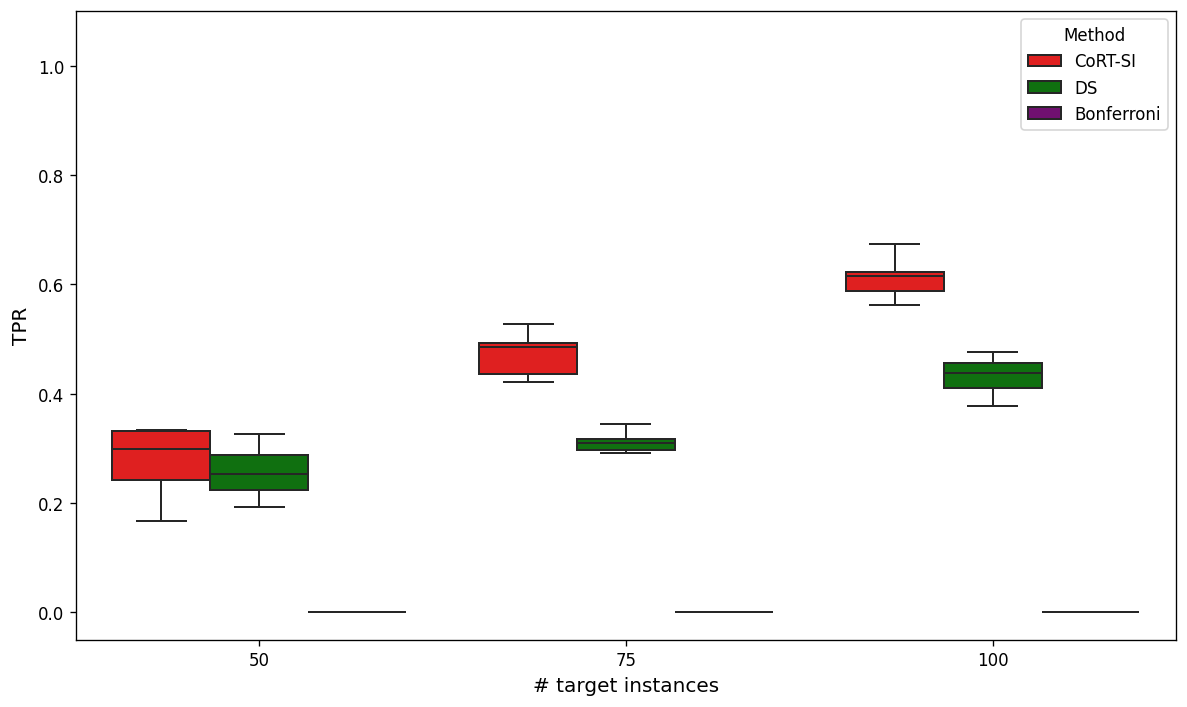

In [ ]:
plt.figure(figsize=(10, 6), dpi=120)

# Create palette map from our methods config
palette = {config['name']: config['color'] for config in methods.values()}

# Draw the grouped boxplot
sns.boxplot(data=df, x='nT', y='TPR', hue='Method', palette=palette, showfliers=False, linewidth=1.2)

plt.xlabel('# target instances', fontsize=12)
plt.ylabel('TPR', fontsize=12)
plt.ylim(-0.05, 1.1)
plt.legend(title='Method')
plt.tight_layout()

# Save figure
plt.savefig('results/tpr_nt_boxplot.pdf', dpi=300)
plt.savefig('results/tpr_nt_boxplot.png', dpi=300)
plt.show()